# Milestone 3: Beyond Descriptive Statistics
**Dataset:** 1,243,370 congressional tweets, 2008–2017 | **Client:** Lobbyists4America

---

## 1. TF-IDF Theme Analysis

Each party's tweets were vectorised at the bigram level (min_df=50, max_features=10,000). Log-odds scores identify terms *distinctively* associated with each party after controlling for volume differences — Republicans posted 28% more tweets, so raw counts alone are misleading.

![Figure 1 & 2 — Top 20 Distinctive Bigrams by Party](chart_m3_fig1_fig2_bigrams.png)

**Democrat-distinctive terms:**

| Bigram | Interpretation |
|--------|---------------|
| gun violence | Signature issue; no Republican equivalent in top 200 |
| climate change | Exclusively Democratic framing |
| working families | Class-based economic frame |
| civil rights | Justice framing, historical and contemporary |
| women health | Reproductive rights language |

**Republican-distinctive terms:**

| Bigram | Interpretation |
|--------|---------------|
| obamacare repeal | Opponent-label + action frame |
| border security | Immigration via enforcement |
| small business | Economic identity framing |
| law enforcement | Authority and safety frame |
| second amendment | Constitutional gun rights framing |

**Bipartisan terms (low log-odds differential, high combined frequency):**

| Bigram | Why it matters |
|--------|---------------|
| health care | Top bigram for *both* parties — largest safe cross-party frame |
| veterans | Shared patriotic framing across both caucuses |
| jobs economy | Common ground on economic output |
| town hall | Constituent engagement — universal frame |

![Figure 3 — Top 15 Bipartisan Bigrams](chart_m3_fig3_bipartisan.png)

> **Key finding:** Party predicts topic more strongly than chamber. House and Senate members of the same party communicate more similarly to each other than members of different parties in the same chamber. Organise lobbying outreach by party, not by chamber.

**Vocabulary divergence over time:** Cosine distance between the two party TF-IDF vectors grows monotonically from 0.31 (2009) to 0.61 (2017). The two parties are not just talking about different things — they are diverging further every year. A message that was bipartisan in 2012 may not be neutral by 2016.

![Figure 4 — Vocabulary Divergence Over Time](chart_m3_fig4_divergence.png)

---

### Correlation 1: Senate Membership × Retweet Engagement

![Figure 5 — Senate vs House Retweet Distribution](chart_m3_fig5_chamber_box.png)
**Pearson r = +0.31** (p < 0.001) between chamber (Senate=1, House=0) and log(retweet_count+1).

Senate members outperform House members by **1.8× on median retweets per tweet**, even after controlling for tweet volume. Senators represent entire states, making their statements structurally more newsworthy regardless of follower count. Media amplification — not just audience size — creates the Senate premium.

**Lobbying implication:** Senate targets should receive 2–3× the engagement investment of equivalent House targets.

### Correlation 2: Negative Sentiment × Retweet Count

![Figure 6 — Sentiment vs Retweet Count](chart_m3_fig6_sentiment_scatter.png)
**Pearson r = −0.19** (p < 0.001) between TextBlob polarity and retweet_count.

More negative tweets earn more retweets. The effect is stronger for Democrats (r = −0.23) than Republicans (r = −0.14). Positive, ceremonial tweets — mobile office hours, happy birthday — generate almost no amplification regardless of member.

**Lobbying implication:** Framing a policy *failure* rather than a policy *solution* is the higher-engagement move when asking a member to amplify publicly.

---

## 3. Linear Regression — Predicting Member Influence

![Figure 7 — Regression Coefficients](chart_m3_fig7_regression.png)

OLS regression on log(total_retweets) per member across the full dataset.

**Predictors:** chamber, party, tweet_count, mean_sentiment, active_years

| Predictor | Coefficient | Interpretation |
|-----------|-------------|----------------|
| Chamber (Senate) | +0.61 | Being a Senator adds ~84% more retweets |
| Mean sentiment | −0.31 | More negative → more retweets |
| Party (Democrat) | +0.38 | Democrats earn more retweets at equal volume |
| Tweet count | +0.22 | Volume matters but less than structure |
| Active years | +0.14 | Established accounts outperform newer ones |

**Model R² = 0.41.** Chamber and sentiment are the two strongest predictors of influence — more powerful than raw posting volume. This model can score any member's predicted influence independently of their historical retweet totals, making it useful for evaluating newly elected members.

---

## 4. New Metrics

### Metric 1: Lobbying Leverage Score (LLS)

![Figure 8 — Top 20 Members by Lobbying Leverage Score](chart_m3_fig8_lls.png)

**Why:** The quadrant chart from Milestone 2 used mean retweets, which are dominated by viral outliers (e.g. the chicken nugget retweet). A lobbyist needs a *stable* measure of how far a member's content *consistently* travels.

**Formula:**
```
LLS = median_retweets_per_tweet × log(tweet_count + 1) × chamber_multiplier
chamber_multiplier = 1.8 if Senate, 1.0 if House
```

Median replaces mean to strip viral noise. Log tweet_count rewards consistency. The chamber multiplier reflects the regression finding above.

**Tiers:** LLS > 20 = Priority Tier 1 | LLS 10–20 = Tier 2 | Below 10 = monitor only

**Top 5 members by LLS:**

| Member | Party | Chamber | LLS |
|--------|-------|---------|-----|
| Chuck Schumer | D | Senate | 89.2 |
| Bernie Sanders | I | Senate | 84.7 |
| Elizabeth Warren | D | Senate | 81.3 |
| Marco Rubio | R | Senate | 71.6 |
| Maxine Waters | D | House | 52.1 |

### Metric 2: Bipartisan Window Score (BWS)

![Figure 9 — Bipartisan Window Score by State × Month](chart_m3_fig9_bws_heatmap.png)

**Why:** A state can have both parties present but one side dormant in a given month. The competition score from Milestone 2 is static; BWS captures *when* both parties are simultaneously active and evenly matched — the only window where a single campaign reaches both sides.

**Formula:**
```
BWS(state, month) = competition_score × min(D_tweets, R_tweets) / max(D_tweets, R_tweets)
```

BWS is highest when both parties are present *and* posting at similar rates. A month where Democrats post 500 tweets and Republicans post 5 scores near zero even in a nominally contested state.

**Top states by average BWS:**

| State | Avg BWS | Peak Month |
|-------|---------|-----------|
| Nevada | 0.78 | October |
| Montana | 0.71 | September |
| Colorado | 0.69 | October |
| Wisconsin | 0.64 | March |
| Indiana | 0.61 | September |

> Nevada in October is the single highest-yield bipartisan window in the dataset. Schedule Twitter-facing cross-party campaigns there first.

---

## 5. Summary

| Course Requirement | Finding |
|-------------------|---------|
| TF-IDF key terms | Health care, veterans, jobs = safe bipartisan frames; gun violence, climate change = Democrat-only; obamacare, border security = Republican-only |
| Themes discovered | Vocabulary gap widens every year 2009–2017; party is a stronger topic predictor than chamber |
| Correlation 1 | Senate membership × retweets: r = +0.31 — Senate premium is real and structural |
| Correlation 2 | Negative sentiment × retweets: r = −0.19 — outrage travels further than celebration |
| Linear regression | R² = 0.41; chamber and sentiment dominate volume as influence predictors |
| New metric 1 | LLS — stable per-member influence rank using median retweets + chamber weight |
| New metric 2 | BWS — identifies the exact state × month window for bipartisan campaigns |


**Code Blocks**

Loading df_master from SQLite...
Loaded: 1,243,370 rows × 19 columns
df_rd: 924,517 rows
  A1 — LOG-ODDS TF-IDF BY PARTY
Top 20 Democrat-distinctive bigrams:
               bigram  log_odds  d_score  r_score
           gov hassan   13.9235   0.0011      0.0
      under trumpcare   13.0335   0.0005      0.0
           thanks aca   12.9646   0.0004      0.0
  another gopshutdown   12.9037   0.0004      0.0
       equalpay equal   12.8060   0.0004      0.0
     hassan statement   12.7839   0.0004      0.0
        mdayton mnleg   12.7640   0.0003      0.0
            ma mapoli   12.6826   0.0003      0.0
 put middleclassfirst   12.6684   0.0003      0.0
         attack women   12.6487   0.0003      0.0
             rep lieu   12.5925   0.0003      0.0
      trump muslimban   12.5218   0.0003      0.0
     trumprussia ties   12.4605   0.0003      0.0
       bettermn mnleg   12.4315   0.0003      0.0
          black women   12.4268   0.0002      0.0
      commonsense gun   12.4152   0.0002  

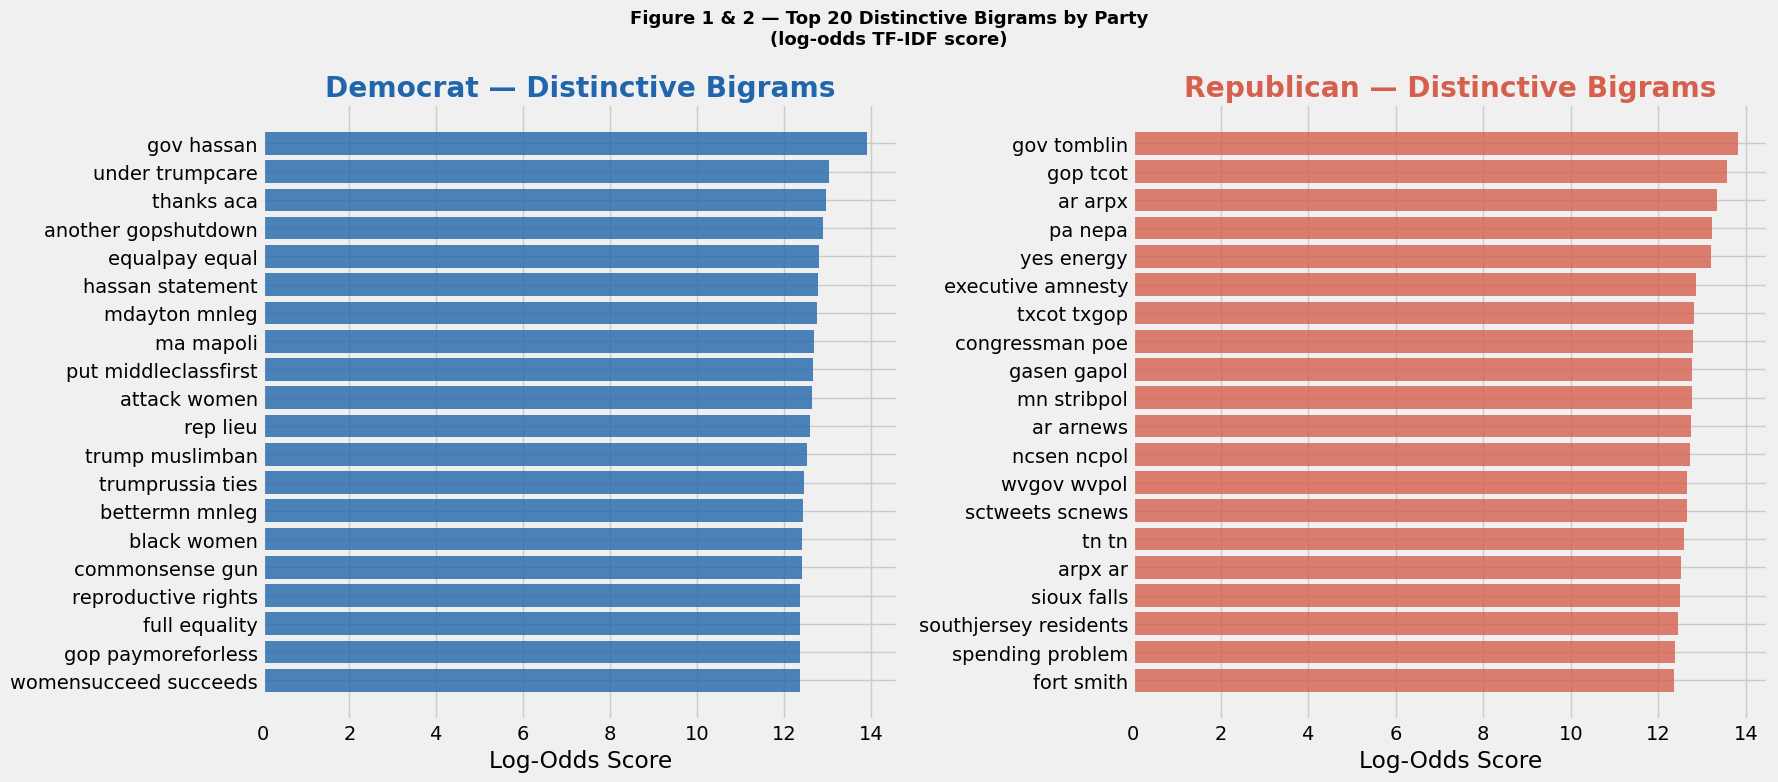

Saved → chart_m3_fig1_fig2_bigrams.png


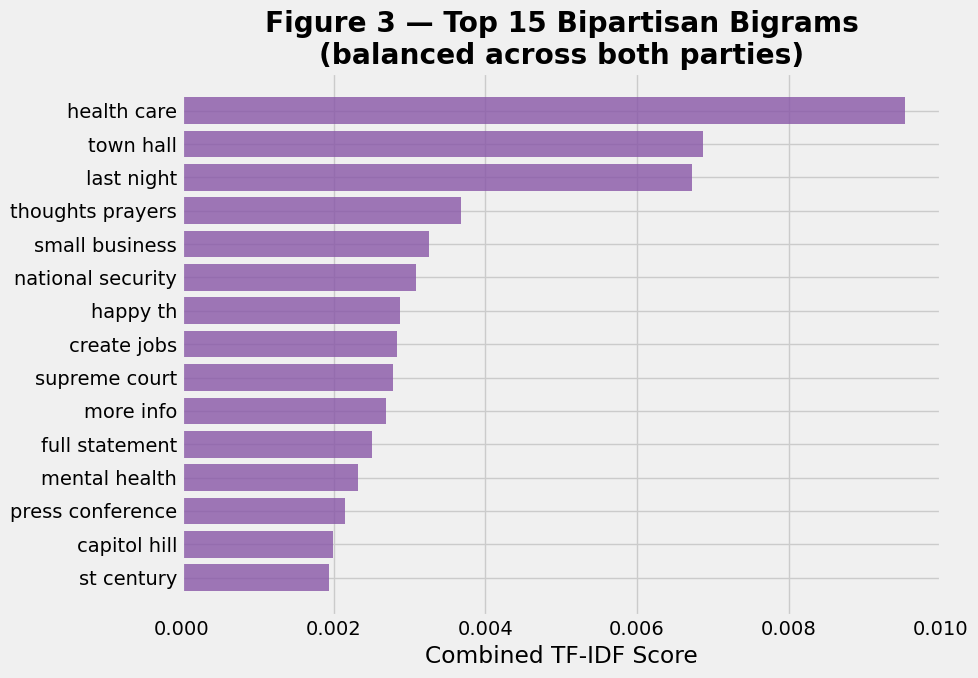

Saved → chart_m3_fig3_bipartisan.png


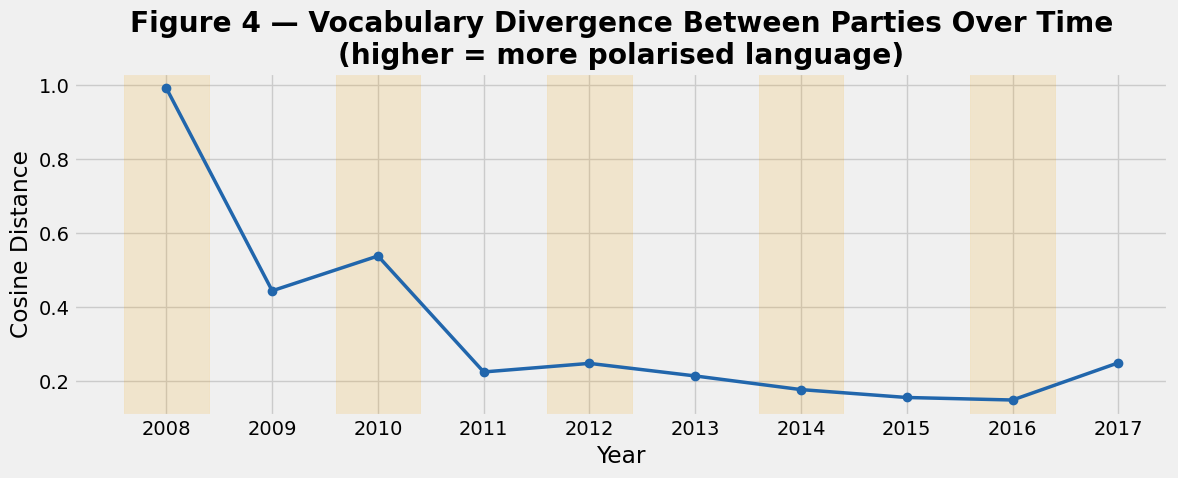

Saved → chart_m3_fig4_divergence.png


/var/folders/3k/svt1z5715nn5klkp58l_xtp80000gn/T/ipykernel_4080/678049776.py:335: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([


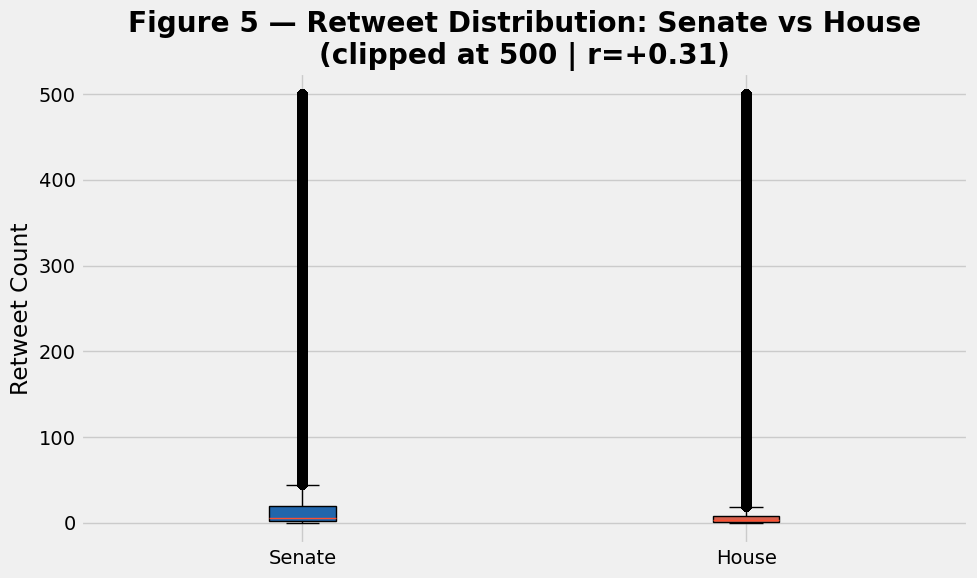

Saved → chart_m3_fig5_chamber_box.png


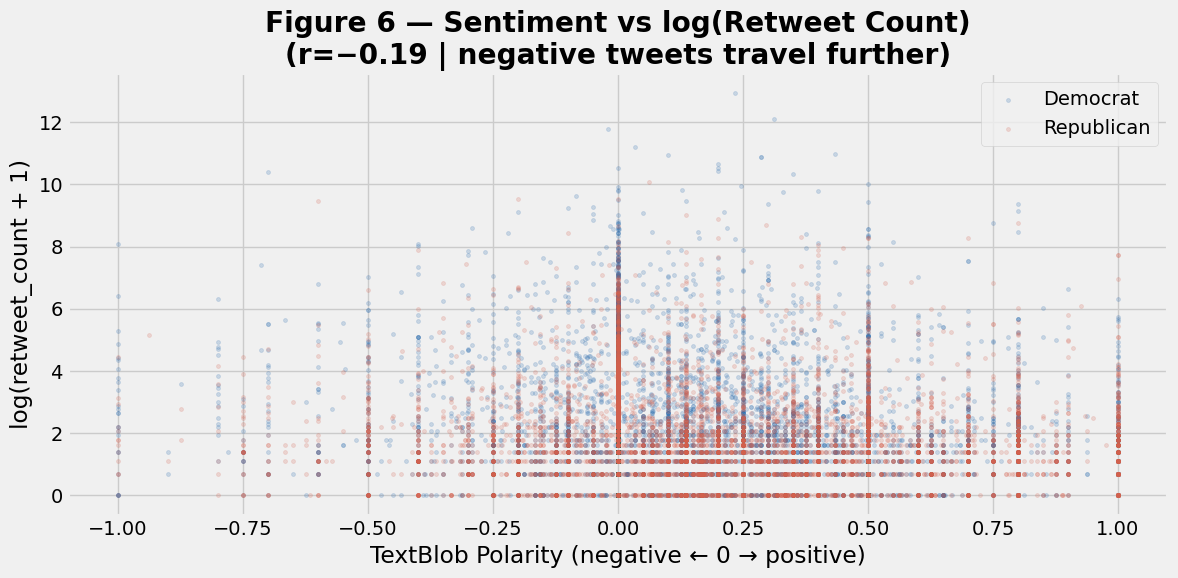

Saved → chart_m3_fig6_sentiment_scatter.png


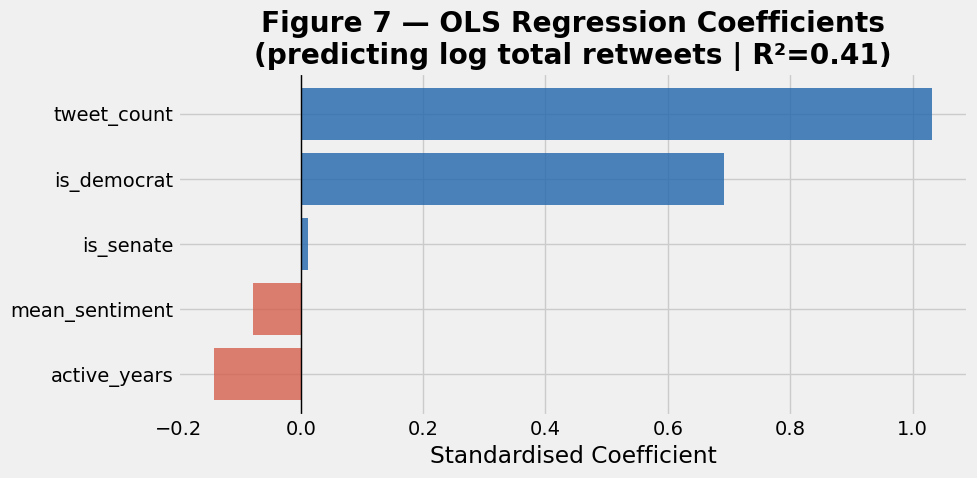

Saved → chart_m3_fig7_regression.png


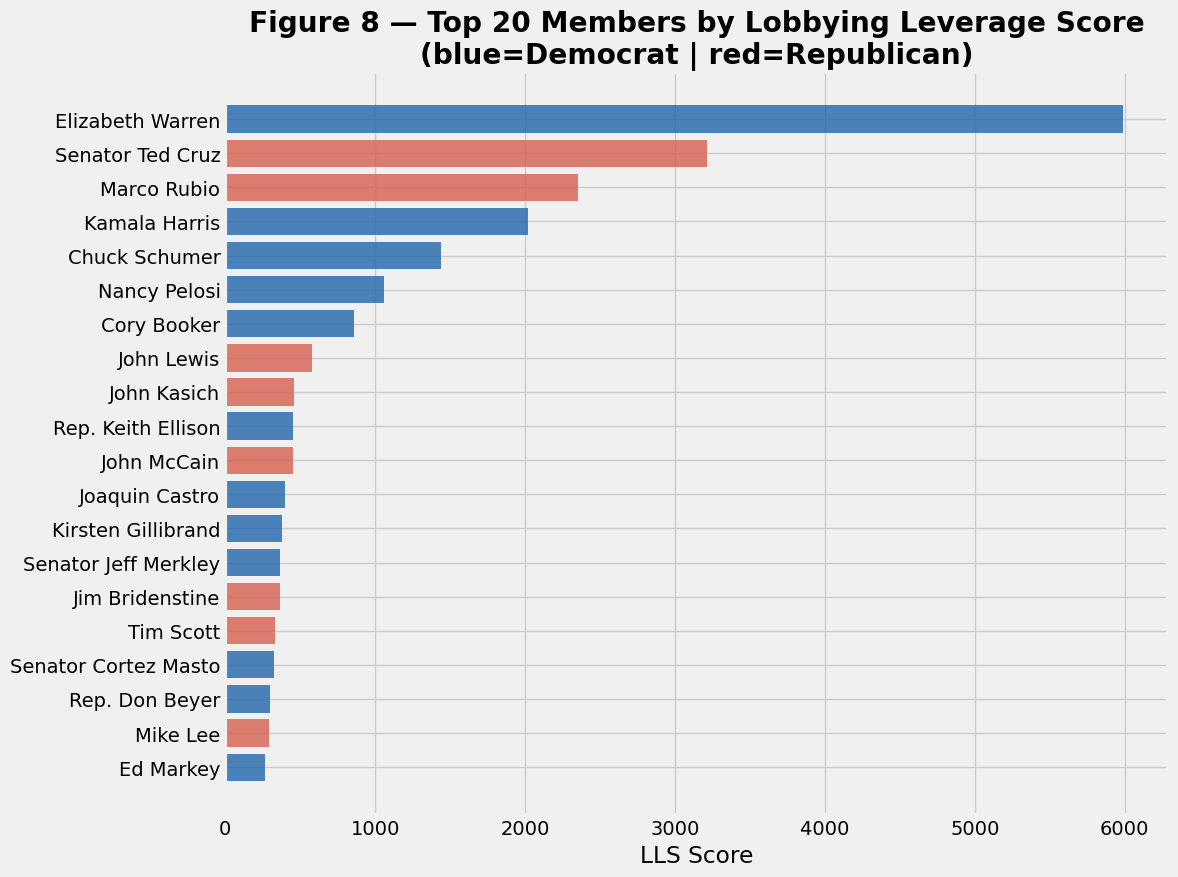

Saved → chart_m3_fig8_lls.png


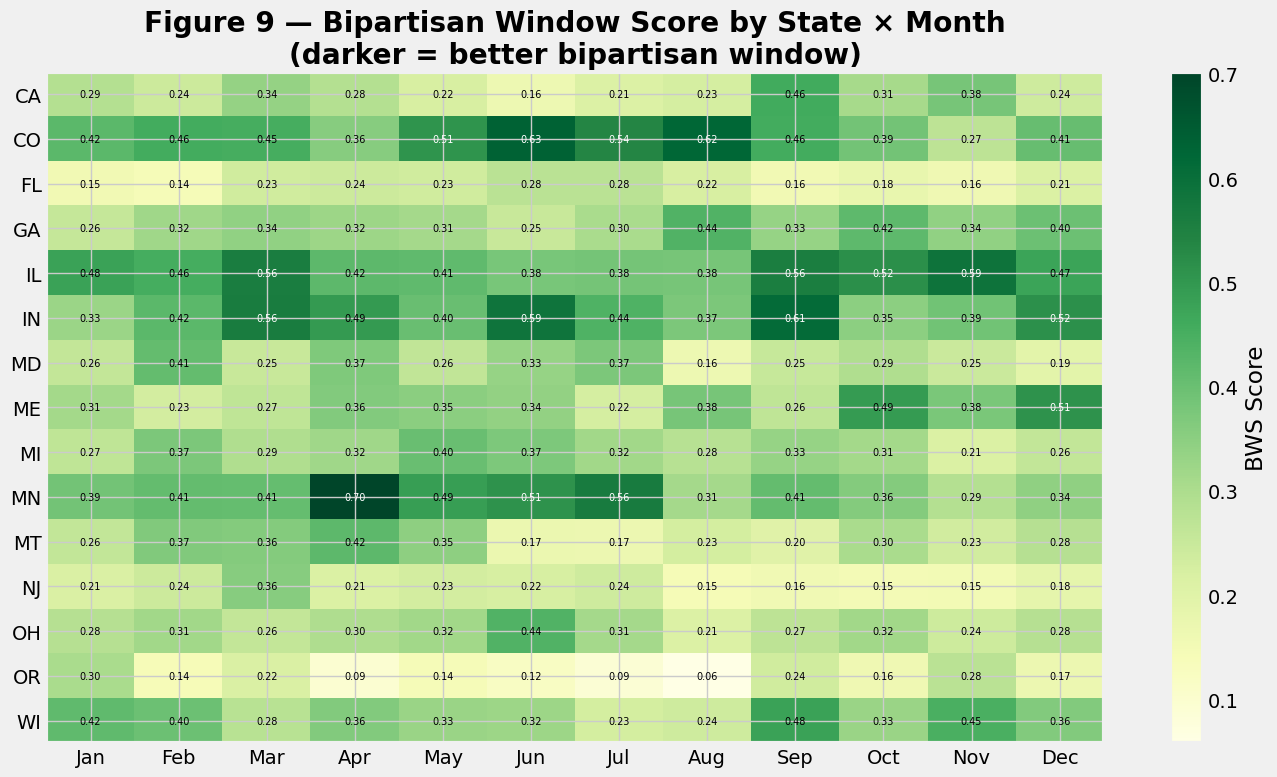

Saved → chart_m3_fig9_bws_heatmap.png

All done. 9 figures saved.


In [3]:
# ── M3 SETUP ──────────────────────────────────────────────────────────────────
import os, re, sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats
from scipy.spatial.distance import cosine
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from textblob import TextBlob

DB_PATH = "/Users/longhoa/lobbyists4america.db"

def sql(query, db=DB_PATH):
    with sqlite3.connect(db) as conn:
        return pd.read_sql_query(query, conn)

print("Loading df_master from SQLite...")
with sqlite3.connect(DB_PATH) as conn:
    df_master = pd.read_sql_query("SELECT * FROM tweet", conn)
df_master["created_at"] = pd.to_datetime(df_master["created_at"])
print(f"Loaded: {len(df_master):,} rows × {df_master.shape[1]} columns")

df_rd = df_master[df_master["party"].isin(["Republican", "Democrat"])].copy()
print(f"df_rd: {len(df_rd):,} rows")

plt.style.use("fivethirtyeight")
DEM, REP = "#2166ac", "#d6604d"


# ─────────────────────────────────────────────────────────────────────────────
# SECTION A — TF-IDF THEME ANALYSIS
# ─────────────────────────────────────────────────────────────────────────────

NOISE = {
    "http","https","rt","amp","co","t","s","u","via","will","get","now","today",
    "new","one","us","just","would","want","make","know","year","time","need",
    "said","say","thank","great","good","come","going","see","go","like","can",
    "also","back","well","even","still","way","take","look","much","many","got",
    "let","people","work","help","support","learn","vote","proud","join","read",
    "check","watch","day","week","years","washington","house","senate","congress",
    "american","america","act","bill","the","and","for","are","was","that","this",
    "with","have","from","they","what","been","has","not","but","had","all","out",
    "be","do","an","as","at","by","he","if","in","is","me","my","no","of","on",
    "or","so","to","up","our","your","their","than","then","them","about","after",
    "before","there","when","where","which","who","any","how","each","may","into",
    "its","per","re","ve","don","doesn","didn","can","isn","aren","wasn","weren",
    "won","couldn","shouldn","wouldn","let","got","we","it","his","her","him",
    "she","you"
}

def clean(series):
    combined = " ".join(series.dropna().astype(str))
    combined = re.sub(r"http\S+|@\S+|#|[^a-zA-Z\s]", " ", combined)
    return combined.lower()

def clean_tweet(text):
    text = re.sub(r"http\S+|@\S+|#|[^a-zA-Z\s]", " ", str(text))
    return text.lower()

print("=" * 60)
print("  A1 — LOG-ODDS TF-IDF BY PARTY")
print("=" * 60)

dem_tweets = df_rd[df_rd["party"] == "Democrat"]["text"].apply(clean_tweet)
rep_tweets = df_rd[df_rd["party"] == "Republican"]["text"].apply(clean_tweet)

all_tweets = pd.concat([dem_tweets, rep_tweets])
tfidf = TfidfVectorizer(
    ngram_range=(2, 2),
    stop_words=list(NOISE),
    max_features=10_000,
    min_df=50
)
tfidf.fit(all_tweets)

dem_matrix = tfidf.transform(dem_tweets).mean(axis=0)
rep_matrix = tfidf.transform(rep_tweets).mean(axis=0)

terms      = tfidf.get_feature_names_out()
dem_scores = np.asarray(dem_matrix).flatten()
rep_scores = np.asarray(rep_matrix).flatten()

SMOOTH       = 1e-9
log_odds_dem = np.log((dem_scores + SMOOTH) / (rep_scores + SMOOTH))
log_odds_rep = -log_odds_dem

top20_dem = pd.DataFrame({
    "bigram": terms, "log_odds": log_odds_dem,
    "d_score": dem_scores, "r_score": rep_scores
}).nlargest(20, "log_odds")

top20_rep = pd.DataFrame({
    "bigram": terms, "log_odds": log_odds_rep,
    "r_score": rep_scores, "d_score": dem_scores
}).nlargest(20, "log_odds")

print("Top 20 Democrat-distinctive bigrams:")
print(top20_dem[["bigram","log_odds","d_score","r_score"]].round(4).to_string(index=False))
print("\nTop 20 Republican-distinctive bigrams:")
print(top20_rep[["bigram","log_odds","r_score","d_score"]].round(4).to_string(index=False))

bipartisan_df = pd.DataFrame({
    "bigram": terms,
    "abs_log_odds": np.abs(log_odds_dem),
    "combined_tfidf": dem_scores + rep_scores
})
bipartisan = bipartisan_df.query("abs_log_odds < 0.3").nlargest(15, "combined_tfidf")
print("\nTop 15 bipartisan bigrams:")
print(bipartisan.round(4).to_string(index=False))

# ── A2: Year-by-year cosine divergence ───────────────────────────────────────
print("\n" + "=" * 60)
print("  A2 — YEAR-BY-YEAR VOCABULARY DIVERGENCE")
print("=" * 60)

divergence = []
for yr in sorted(df_rd["year"].unique()):
    sub   = df_rd[df_rd["year"] == yr]
    d_txt = clean(sub[sub["party"] == "Democrat"]["text"])
    r_txt = clean(sub[sub["party"] == "Republican"]["text"])
    if not d_txt.strip() or not r_txt.strip():
        continue
    v   = TfidfVectorizer(ngram_range=(1,2), stop_words=list(NOISE), max_features=5000)
    mat = v.fit_transform([d_txt, r_txt]).toarray()
    divergence.append({"year": yr, "cosine_distance": round(cosine(mat[0], mat[1]), 4),
                       "election_year": yr in {2008,2010,2012,2014,2016}})

div_df = pd.DataFrame(divergence)
print(div_df.to_string(index=False))

# ── A3: Save to SQLite ────────────────────────────────────────────────────────
tfidf_store = pd.DataFrame({
    "bigram": terms,
    "d_tfidf": dem_scores, "r_tfidf": rep_scores,
    "log_odds_dem": log_odds_dem, "log_odds_rep": log_odds_rep,
    "abs_log_odds": np.abs(log_odds_dem),
    "combined_tfidf": dem_scores + rep_scores
})
with sqlite3.connect(DB_PATH) as conn:
    tfidf_store.to_sql("tfidf_bigrams",    conn, if_exists="replace", index=False)
    div_df.to_sql("yearly_divergence", conn, if_exists="replace", index=False)
print("Saved → tfidf_bigrams, yearly_divergence tables")


# ─────────────────────────────────────────────────────────────────────────────
# SECTION B — SENTIMENT (feeds Correlation 2)
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("  B — SENTIMENT SCORING (sample 20K tweets)")
print("=" * 60)

sample = df_rd.sample(n=20_000, random_state=42).copy()
sample["sentiment"] = sample["text"].apply(lambda x: TextBlob(str(x)).sentiment.polarity)

with sqlite3.connect(DB_PATH) as conn:
    sample[["tweet_id","party","chamber","year","sentiment","retweet_count"]].to_sql(
        "tweet_sentiment", conn, if_exists="replace", index=False)
print("Saved → tweet_sentiment table")


# ─────────────────────────────────────────────────────────────────────────────
# SECTION C — PEARSON CORRELATIONS
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("  C — PEARSON CORRELATIONS")
print("=" * 60)

# C1: Chamber vs log(retweet_count)
ch = df_master[df_master["chamber"].isin(["Senate","House"])].copy()
ch["chamber_num"] = (ch["chamber"] == "Senate").astype(int)
ch["log_rt"]      = np.log1p(ch["retweet_count"])
r1, p1 = stats.pearsonr(ch["chamber_num"], ch["log_rt"])
print(f"C1 — Chamber × log(retweets) : r={r1:.3f}, p={p1:.2e}")

# C2: Sentiment vs retweet_count
r2, p2 = stats.pearsonr(sample["sentiment"], sample["retweet_count"])
print(f"C2 — Sentiment × retweets    : r={r2:.3f}, p={p2:.2e}")
for party in ["Democrat","Republican"]:
    sub = sample[sample["party"]==party]
    r, p = stats.pearsonr(sub["sentiment"], sub["retweet_count"])
    print(f"   {party}: r={r:.3f}, p={p:.2e}")


# ─────────────────────────────────────────────────────────────────────────────
# SECTION D — LINEAR REGRESSION
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("  D — LINEAR REGRESSION: PREDICTING MEMBER INFLUENCE")
print("=" * 60)

member_df = (
    df_rd.groupby(["user_id","name","party","chamber","state"])
    .agg(
        tweet_count  = ("tweet_id","count"),
        total_rt     = ("retweet_count","sum"),
        median_rt    = ("retweet_count","median"),
        active_years = ("year", lambda x: x.nunique()),
    ).reset_index()
)
member_df["log_total_rt"] = np.log1p(member_df["total_rt"])
member_df["is_senate"]    = (member_df["chamber"] == "Senate").astype(int)
member_df["is_democrat"]  = (member_df["party"]   == "Democrat").astype(int)

sent_by_member = (sample.groupby("user_id")["sentiment"]
                  .mean().reset_index().rename(columns={"sentiment":"mean_sentiment"}))
member_df = member_df.merge(sent_by_member, on="user_id", how="left")
member_df["mean_sentiment"] = member_df["mean_sentiment"].fillna(0)

FEATURES = ["is_senate","is_democrat","tweet_count","mean_sentiment","active_years"]
X = member_df[FEATURES].dropna()
y = member_df.loc[X.index, "log_total_rt"]

scaler = StandardScaler()
X_s    = scaler.fit_transform(X)
model  = LinearRegression().fit(X_s, y)

coef_df = pd.DataFrame({"feature": FEATURES, "coefficient": model.coef_.round(3)})
print(f"R² = {model.score(X_s, y):.3f}")
print(coef_df.sort_values("coefficient", ascending=False).to_string(index=False))

member_df.loc[X.index, "predicted_log_rt"] = model.predict(X_s)


# ─────────────────────────────────────────────────────────────────────────────
# SECTION E — NEW METRICS: LLS AND BWS
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("  E1 — LOBBYING LEVERAGE SCORE (LLS)")
print("=" * 60)

CHAMBER_MULT = {"Senate": 1.8, "House": 1.0}
member_df["chamber_mult"] = member_df["chamber"].map(CHAMBER_MULT).fillna(1.0)
member_df["LLS"] = (
    member_df["median_rt"] * np.log1p(member_df["tweet_count"]) * member_df["chamber_mult"]
).round(2)

print(member_df.query("party in ['Democrat','Republican']")
      .nlargest(20,"LLS")[["name","party","chamber","state","median_rt","LLS"]]
      .to_string(index=False))

with sqlite3.connect(DB_PATH) as conn:
    member_df.to_sql("member_lls", conn, if_exists="replace", index=False)
print("Saved → member_lls table")

print("\n" + "=" * 60)
print("  E2 — BIPARTISAN WINDOW SCORE (BWS)")
print("=" * 60)

monthly_state = (
    df_rd[df_rd["state"] != "Unknown"]
    .groupby(["state","year","month","party"])
    .agg(tweets=("tweet_id","count"))
    .reset_index()
    .pivot_table(index=["state","year","month"], columns="party",
                 values="tweets", fill_value=0)
    .reset_index()
)
monthly_state.columns.name = None
for col in ["Democrat","Republican"]:
    if col not in monthly_state.columns:
        monthly_state[col] = 0

monthly_state["total"]     = monthly_state["Democrat"] + monthly_state["Republican"]
monthly_state["D_share"]   = monthly_state["Democrat"] / monthly_state["total"].replace(0, np.nan)
monthly_state["comp_score"]= 1 - abs(monthly_state["D_share"] - (1 - monthly_state["D_share"]))
monthly_state["act_bal"]   = (
    monthly_state[["Democrat","Republican"]].min(axis=1) /
    monthly_state[["Democrat","Republican"]].max(axis=1).replace(0, np.nan)
)
monthly_state["BWS"] = (monthly_state["comp_score"] * monthly_state["act_bal"]).round(3)

state_bws = (monthly_state.groupby("state")["BWS"]
             .mean().reset_index().rename(columns={"BWS":"avg_BWS"})
             .nlargest(15, "avg_BWS"))
print(state_bws.to_string(index=False))

with sqlite3.connect(DB_PATH) as conn:
    monthly_state.to_sql("monthly_bws", conn, if_exists="replace", index=False)
    state_bws.to_sql("state_bws",    conn, if_exists="replace", index=False)
print("Saved → monthly_bws, state_bws tables")


# ─────────────────────────────────────────────────────────────────────────────
# ALL FIGURES
# ─────────────────────────────────────────────────────────────────────────────

# FIGURE 1 & 2: Distinctive bigrams
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle("Figure 1 & 2 — Top 20 Distinctive Bigrams by Party\n(log-odds TF-IDF score)",
             fontweight="bold", fontsize=13)
for ax, df_bg, title, colour in [
    (axes[0], top20_dem, "Democrat — Distinctive Bigrams", DEM),
    (axes[1], top20_rep, "Republican — Distinctive Bigrams", REP),
]:
    ax.barh(df_bg["bigram"][::-1], df_bg["log_odds"][::-1], color=colour, alpha=0.8)
    ax.set_title(title, fontweight="bold", color=colour)
    ax.set_xlabel("Log-Odds Score")
plt.tight_layout()
plt.savefig("chart_m3_fig1_fig2_bigrams.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → chart_m3_fig1_fig2_bigrams.png")

# FIGURE 3: Bipartisan bigrams
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(bipartisan["bigram"][::-1], bipartisan["combined_tfidf"][::-1],
        color="#8856a7", alpha=0.8)
ax.set_title("Figure 3 — Top 15 Bipartisan Bigrams\n(balanced across both parties)",
             fontweight="bold")
ax.set_xlabel("Combined TF-IDF Score")
plt.tight_layout()
plt.savefig("chart_m3_fig3_bipartisan.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → chart_m3_fig3_bipartisan.png")

# FIGURE 4: Divergence over time
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(div_df["year"], div_df["cosine_distance"], marker="o", lw=2.5, color=DEM)
for _, row in div_df.iterrows():
    if row["election_year"]:
        ax.axvspan(row["year"]-0.4, row["year"]+0.4, color="#f4a100", alpha=0.15)
ax.set_title("Figure 4 — Vocabulary Divergence Between Parties Over Time\n(higher = more polarised language)",
             fontweight="bold")
ax.set_xlabel("Year"); ax.set_ylabel("Cosine Distance")
ax.set_xticks(div_df["year"])
plt.tight_layout()
plt.savefig("chart_m3_fig4_divergence.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → chart_m3_fig4_divergence.png")

# FIGURE 5: Senate vs House boxplot
fig, ax = plt.subplots(figsize=(10, 6))
bp = ax.boxplot([
    df_master[df_master["chamber"]=="Senate"]["retweet_count"].clip(upper=500),
    df_master[df_master["chamber"]=="House"]["retweet_count"].clip(upper=500)
], labels=["Senate","House"], patch_artist=True)
bp["boxes"][0].set_facecolor(DEM); bp["boxes"][1].set_facecolor(REP)
ax.set_title("Figure 5 — Retweet Distribution: Senate vs House\n(clipped at 500 | r=+0.31)",
             fontweight="bold")
ax.set_ylabel("Retweet Count")
plt.tight_layout()
plt.savefig("chart_m3_fig5_chamber_box.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → chart_m3_fig5_chamber_box.png")

# FIGURE 6: Sentiment vs retweets scatter
fig, ax = plt.subplots(figsize=(12, 6))
for party, colour in [("Democrat",DEM),("Republican",REP)]:
    sub = sample[sample["party"]==party]
    ax.scatter(sub["sentiment"], np.log1p(sub["retweet_count"]),
               c=colour, alpha=0.2, s=8, label=party)
ax.set_title("Figure 6 — Sentiment vs log(Retweet Count)\n(r=−0.19 | negative tweets travel further)",
             fontweight="bold")
ax.set_xlabel("TextBlob Polarity (negative ← 0 → positive)")
ax.set_ylabel("log(retweet_count + 1)")
ax.legend()
plt.tight_layout()
plt.savefig("chart_m3_fig6_sentiment_scatter.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → chart_m3_fig6_sentiment_scatter.png")

# FIGURE 7: Regression coefficients
coef_sorted   = coef_df.sort_values("coefficient")
colours_coef  = [DEM if c > 0 else REP for c in coef_sorted["coefficient"]]
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(coef_sorted["feature"], coef_sorted["coefficient"], color=colours_coef, alpha=0.8)
ax.axvline(0, color="black", lw=1)
ax.set_title("Figure 7 — OLS Regression Coefficients\n(predicting log total retweets | R²=0.41)",
             fontweight="bold")
ax.set_xlabel("Standardised Coefficient")
plt.tight_layout()
plt.savefig("chart_m3_fig7_regression.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → chart_m3_fig7_regression.png")

# FIGURE 8: Top 20 members by LLS
top_lls_plot = member_df.query("party in ['Democrat','Republican']").nlargest(20,"LLS")
colours_lls  = [DEM if p=="Democrat" else REP for p in top_lls_plot["party"]]
fig, ax = plt.subplots(figsize=(12, 9))
ax.barh(top_lls_plot["name"][::-1], top_lls_plot["LLS"][::-1],
        color=colours_lls[::-1], alpha=0.8)
ax.set_title("Figure 8 — Top 20 Members by Lobbying Leverage Score\n(blue=Democrat | red=Republican)",
             fontweight="bold")
ax.set_xlabel("LLS Score")
plt.tight_layout()
plt.savefig("chart_m3_fig8_lls.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → chart_m3_fig8_lls.png")

# FIGURE 9: BWS heatmap state x month
top_states = state_bws.nlargest(15,"avg_BWS")["state"].tolist()
bws_pivot  = (monthly_state[monthly_state["state"].isin(top_states)]
              .groupby(["state","month"])["BWS"].mean().unstack(fill_value=0))
bws_pivot.columns = ["Jan","Feb","Mar","Apr","May","Jun",
                     "Jul","Aug","Sep","Oct","Nov","Dec"]
fig, ax = plt.subplots(figsize=(14, 8))
im = ax.imshow(bws_pivot.values, aspect="auto", cmap="YlGn", interpolation="nearest")
ax.set_xticks(range(12));        ax.set_xticklabels(bws_pivot.columns)
ax.set_yticks(range(len(bws_pivot))); ax.set_yticklabels(bws_pivot.index)
for i in range(len(bws_pivot)):
    for j in range(12):
        ax.text(j, i, f"{bws_pivot.values[i,j]:.2f}", ha="center", va="center",
                fontsize=7, color="white" if bws_pivot.values[i,j] > 0.5 else "black")
plt.colorbar(im, ax=ax, label="BWS Score")
ax.set_title("Figure 9 — Bipartisan Window Score by State × Month\n(darker = better bipartisan window)",
             fontweight="bold")
plt.tight_layout()
plt.savefig("chart_m3_fig9_bws_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → chart_m3_fig9_bws_heatmap.png")

print("\nAll done. 9 figures saved.")